<h1>Built a character-level text generation model</h1>

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import image

In [10]:
data = open("/home/samani/Documents/projects/deep-learning/data/dinos.txt", "r").read()
print(data)

Aachenosaurus
Aardonyx
Abdallahsaurus
Abelisaurus
Abrictosaurus
Abrosaurus
Abydosaurus
Acanthopholis
Achelousaurus
Acheroraptor
Achillesaurus
Achillobator
Acristavus
Acrocanthosaurus
Acrotholus
Actiosaurus
Adamantisaurus
Adasaurus
Adelolophus
Adeopapposaurus
Aegyptosaurus
Aeolosaurus
Aepisaurus
Aepyornithomimus
Aerosteon
AetonyxAfromimus
Afrovenator
Agathaumas
Aggiosaurus
Agilisaurus
Agnosphitys
Agrosaurus
Agujaceratops
Agustinia
Ahshislepelta
Airakoraptor
Ajancingenia
Ajkaceratops
Alamosaurus
Alaskacephale
Albalophosaurus
Albertaceratops
Albertadromeus
Albertavenator
Albertonykus
Albertosaurus
Albinykus
Albisaurus
Alcovasaurus
Alectrosaurus
Aletopelta
Algoasaurus
Alioramus
Aliwalia
Allosaurus
Almas
Alnashetri
Alocodon
Altirhinus
Altispinax
Alvarezsaurus
Alwalkeria
Alxasaurus
Amargasaurus
Amargastegos
Amargatitanis
Amazonsaurus
Ammosaurus
Ampelosaurus
Amphicoelias
Amphicoelicaudia
Amphisaurus
Amtocephale
Amtosaurus
Amurosaurus
Amygdalodon
Anabisetia
Anasazisaurus
Anatosaurus
Anatotitan

In [11]:
data = data.lower()
chars = list(set(data))
print(len(data))
print(len(chars))

19909
27


In [12]:
chars = sorted(chars)
print(chars)

['\n', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [63]:
char_to_idx = {char: idx for idx, char in enumerate(chars)}
idx_to_char = {idx: char for idx, char in enumerate(chars)}
print(char_to_idx)
print(idx_to_char)

{'\n': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
{0: '\n', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


<h3>Gradient Clipping</h3>
<h4>Source: <a href="https://www.coursera.org/learn/nlp-sequence-models?" target="_blank">Deep Learning AI. Sequence Models</a></h4>

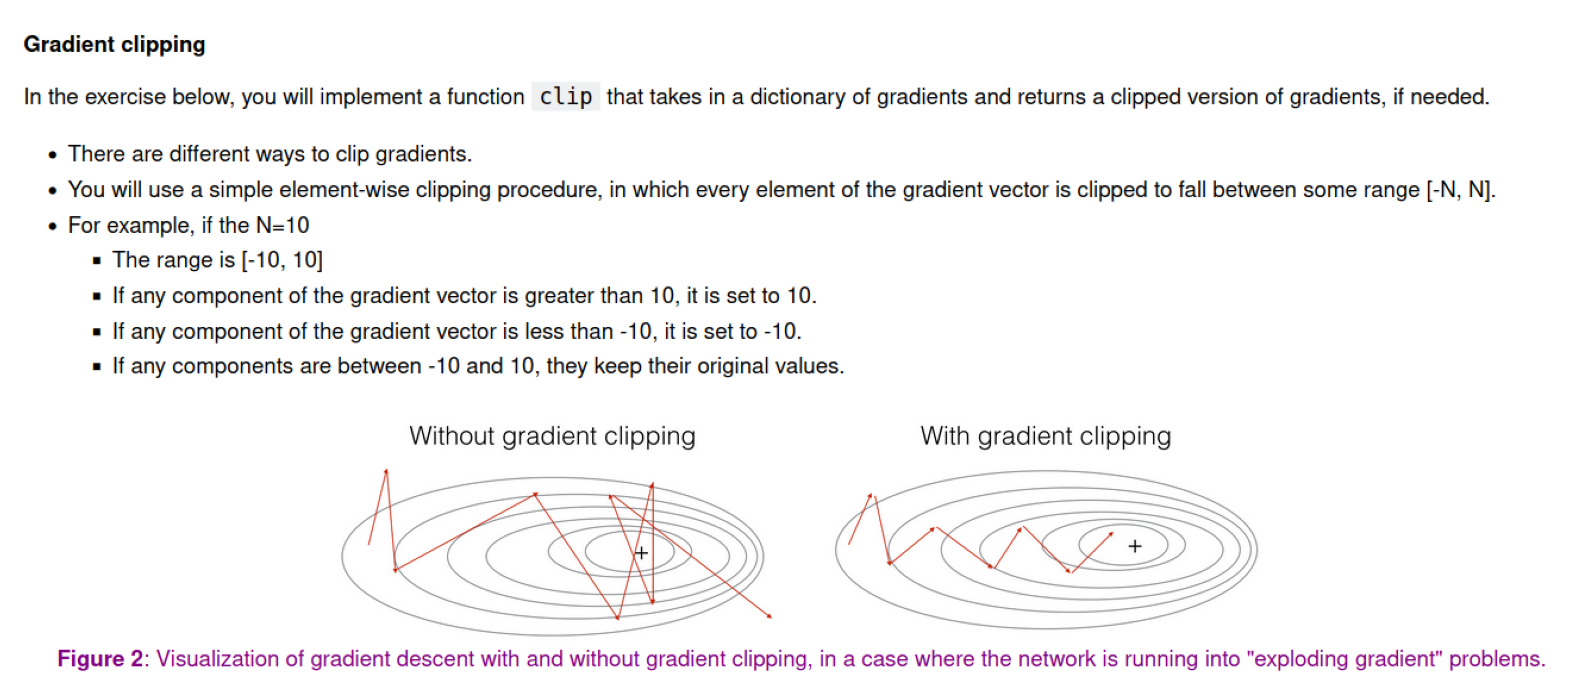

In [27]:
plt.figure(figsize=(20, 10))
path = "clip.png"
img = image.imread(path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [29]:
def clip(gradients, min_val, max_val):

    for gradient in gradients.values():
        np.clip(gradient, min_val, max_val, out=gradient)

    return gradients

In [30]:
np.random.seed(3)
dWax = np.array([range(10)])
dWaa = np.array([range(10)])
dWya = np.array([range(10)])
db = np.array([range(10)])
dby = np.array([range(10)])
gradients = {"dWax": dWax, "dWaa": dWaa, "dWya": dWya, "db": db, "dby": dby}
print(gradients)

{'dWax': array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]), 'dWaa': array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]), 'dWya': array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]), 'db': array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]), 'dby': array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])}


In [32]:
print(clip(gradients, 3, 6))

{'dWax': array([[3, 3, 3, 3, 4, 5, 6, 6, 6, 6]]), 'dWaa': array([[3, 3, 3, 3, 4, 5, 6, 6, 6, 6]]), 'dWya': array([[3, 3, 3, 3, 4, 5, 6, 6, 6, 6]]), 'db': array([[3, 3, 3, 3, 4, 5, 6, 6, 6, 6]]), 'dby': array([[3, 3, 3, 3, 4, 5, 6, 6, 6, 6]])}


<h3>Sampling</h3>

<h4>Assume that your model is trained, and you would like to generate new text (characters). The process of generation is explained in the picture below:</h4>

<h4>Source: <a href="https://www.coursera.org/learn/nlp-sequence-models?" target="_blank">Deep Learning AI. Sequence Models</a></h4>


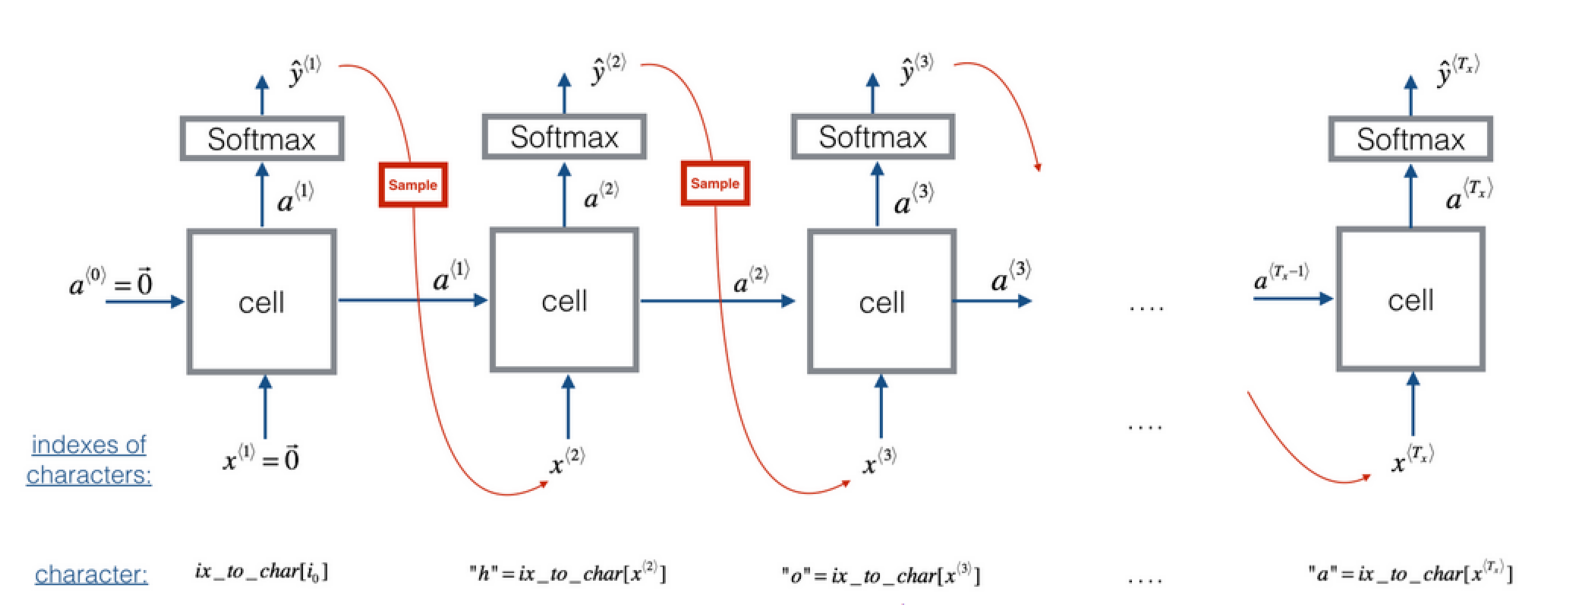

In [33]:
plt.figure(figsize=(20, 10))
path = "sampling.png"
img = image.imread(path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [56]:
def sample(parameters, char_to_ix, seed):
    """
    Sample a sequence of characters according to a sequence of probability distributions output of the RNN

    Arguments:
    parameters -- Python dictionary containing the parameters Waa, Wax, Wya, by, and b. 
    char_to_ix -- Python dictionary mapping each character to an index.
    seed -- Used for grading purposes. Do not worry about it.

    Returns:
    indices -- A list of length n containing the indices of the sampled characters.
    """
    Waa, Wax, Wya, by, b = parameters['Waa'], parameters['Wax'], parameters['Wya'], parameters['by'], parameters['b']
    vocab_size = by.shape[0]
    n_a = Waa.shape[1]
    
    x = np.zeros((vocab_size, 1))
    a_prev = np.zeros((n_a, 1))

    indices = []
    idx = -1
    
    counter = 0
    newline_character = char_to_ix['\n']
    
    while (idx != newline_character and counter != 50):
        
        a = np.tanh(np.dot(Wax, x) + np.dot(Waa, a_prev) + b)
        z = np.dot(Wya, a) + by
        y = softmax(z)
        
        np.random.seed(counter + seed) 
        idx = np.random.choice(range(vocab_size), p=y.ravel())
        indices.append(idx)
        
        x = np.zeros((vocab_size, 1))
        x[idx] = 1
        a_prev = a
        
        seed += 1
        counter +=1

    if (counter == 50):
        indices.append(char_to_ix['\n'])
    
    return indices

<h2>Implement the optimization process (one step of stochastic gradient descent)</h2>

In [58]:
# needed functions

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def smooth(loss, cur_loss):
    return loss * 0.999 + cur_loss * 0.001

def print_sample(sample_ix, ix_to_char):
    txt = ''.join(ix_to_char[ix] for ix in sample_ix)
    txt = txt[0].upper() + txt[1:] 
    print ('%s' % (txt, ), end='')
    

def get_sample(sample_ix, ix_to_char):
    txt = ''.join(ix_to_char[ix] for ix in sample_ix)
    txt = txt[0].upper() + txt[1:]
    return txt

def get_initial_loss(vocab_size, seq_length):
    return -np.log(1.0/vocab_size)*seq_length


def initialize_parameters(n_a, n_x, n_y):
  
    Wax = np.random.randn(n_a, n_x)*0.01 
    Waa = np.random.randn(n_a, n_a)*0.01 
    Wya = np.random.randn(n_y, n_a)*0.01 
    b = np.zeros((n_a, 1)) 
    by = np.zeros((n_y, 1)) 
    
    parameters = {"Wax": Wax, "Waa": Waa, "Wya": Wya, "b": b,"by": by}
    
    return parameters

def rnn_step_forward(parameters, a_prev, x):
    
    Waa, Wax, Wya, by, b = parameters['Waa'], parameters['Wax'], parameters['Wya'], parameters['by'], parameters['b']
    a_next = np.tanh(np.dot(Wax, x) + np.dot(Waa, a_prev) + b) 
    p_t = softmax(np.dot(Wya, a_next) + by) 
    
    return a_next, p_t

def rnn_step_backward(dy, gradients, parameters, x, a, a_prev):
    
    gradients['dWya'] += np.dot(dy, a.T)
    gradients['dby'] += dy
    da = np.dot(parameters['Wya'].T, dy) + gradients['da_next'] 
    daraw = (1 - a * a) * da 
    gradients['db'] += daraw
    gradients['dWax'] += np.dot(daraw, x.T)
    gradients['dWaa'] += np.dot(daraw, a_prev.T)
    gradients['da_next'] = np.dot(parameters['Waa'].T, daraw)
    return gradients

def update_parameters(parameters, gradients, lr):

    parameters['Wax'] += -lr * gradients['dWax']
    parameters['Waa'] += -lr * gradients['dWaa']
    parameters['Wya'] += -lr * gradients['dWya']
    parameters['b']  += -lr * gradients['db']
    parameters['by']  += -lr * gradients['dby']
    return parameters

def rnn_forward(X, Y, a0, parameters, vocab_size = 27):
    
    x, a, y_hat = {}, {}, {}
    
    a[-1] = np.copy(a0)
    
    loss = 0
    
    for t in range(len(X)):
        
        x[t] = np.zeros((vocab_size,1)) 
        if (X[t] != None):
            x[t][X[t]] = 1
        
        a[t], y_hat[t] = rnn_step_forward(parameters, a[t-1], x[t])
        
        loss -= np.log(y_hat[t][Y[t],0])
        
    cache = (y_hat, a, x)
        
    return loss, cache

def rnn_backward(X, Y, parameters, cache):
    
    gradients = {}
    
    (y_hat, a, x) = cache
    Waa, Wax, Wya, by, b = parameters['Waa'], parameters['Wax'], parameters['Wya'], parameters['by'], parameters['b']
    
    gradients['dWax'], gradients['dWaa'], gradients['dWya'] = np.zeros_like(Wax), np.zeros_like(Waa), np.zeros_like(Wya)
    gradients['db'], gradients['dby'] = np.zeros_like(b), np.zeros_like(by)
    gradients['da_next'] = np.zeros_like(a[0])
    
    for t in reversed(range(len(X))):
        
        dy = np.copy(y_hat[t])
        dy[Y[t]] -= 1
        gradients = rnn_step_backward(dy, gradients, parameters, x[t], a[t], a[t-1])

    return gradients, a

In [59]:
def optimize(X, Y, a_prev, parameters, learning_rate = 0.01):
    """
    Execute one step of the optimization to train the model.
    
    Arguments:
    X -- list of integers, where each integer is a number that maps to a character in the vocabulary.
    Y -- list of integers, exactly the same as X but shifted one index to the left.
    a_prev -- previous hidden state.
    parameters -- python dictionary containing:
                        Wax -- Weight matrix multiplying the input, numpy array of shape (n_a, n_x)
                        Waa -- Weight matrix multiplying the hidden state, numpy array of shape (n_a, n_a)
                        Wya -- Weight matrix relating the hidden-state to the output, numpy array of shape (n_y, n_a)
                        b --  Bias, numpy array of shape (n_a, 1)
                        by -- Bias relating the hidden-state to the output, numpy array of shape (n_y, 1)
    learning_rate -- learning rate for the model.
    
    Returns:
    loss -- value of the loss function (cross-entropy)
    gradients -- python dictionary containing:
                        dWax -- Gradients of input-to-hidden weights, of shape (n_a, n_x)
                        dWaa -- Gradients of hidden-to-hidden weights, of shape (n_a, n_a)
                        dWya -- Gradients of hidden-to-output weights, of shape (n_y, n_a)
                        db -- Gradients of bias vector, of shape (n_a, 1)
                        dby -- Gradients of output bias vector, of shape (n_y, 1)
    a[len(X)-1] -- the last hidden state, of shape (n_a, 1)
    """
    
    loss, cache = rnn_forward(X, Y, a_prev, parameters)
    gradients, a = rnn_backward(X, Y, parameters, cache)
    gradients = clip(gradients, -5, 5)
    parameters = update_parameters(parameters, gradients, learning_rate)
    
    return loss, gradients, a[len(X)-1]

In [60]:
def model(data_x, ix_to_char, char_to_ix, num_iterations = 35000, n_a = 50, dino_names=7, vocab_size=27, verbose=False):
    """
    Trains the model and generates dinosaur names. 
    
    Arguments:
    data_x -- text corpus, divided in words
    ix_to_char -- dictionary that maps the index to a character
    char_to_ix -- dictionary that maps a character to an index
    num_iterations -- number of iterations to train the model for
    n_a -- number of units of the RNN cell
    dino_names -- number of dinosaur names you want to sample at each iteration. 
    vocab_size -- number of unique characters found in the text (size of the vocabulary)
    
    Returns:
    parameters -- learned parameters
    """
    n_x, n_y = vocab_size, vocab_size
    parameters = initialize_parameters(n_a, n_x, n_y)
    loss = get_initial_loss(vocab_size, dino_names)
    
    examples = [x.strip() for x in data_x]
    
    np.random.seed(0)
    np.random.shuffle(examples)
    
    a_prev = np.zeros((n_a, 1))
    last_dino_name = "abc"
    
    for j in range(num_iterations):
        
        idx = j % len(examples)

        single_example = examples[idx]
        single_example_chars = [c for c in single_example]
        single_example_ix = [char_to_ix[c] for c in single_example_chars]

        X = [None] + single_example_ix

        ix_newline = char_to_ix['\n']
        Y = single_example_ix + [ix_newline]

        curr_loss, gradients, a_prev = optimize(X, Y, a_prev, parameters, learning_rate=0.01)
        
        if verbose and j in [0, len(examples) -1, len(examples)]:
            print("j = " , j, "idx = ", idx,) 
        if verbose and j in [0]:
            print("single_example =", single_example)
            print("single_example_chars", single_example_chars)
            print("single_example_ix", single_example_ix)
            print(" X = ", X, "\n", "Y =       ", Y, "\n")
        
        loss = smooth(loss, curr_loss)

        if j % 2000 == 0:
            
            print('Iteration: %d, Loss: %f' % (j, loss) + '\n')
            
            seed = 0
            for name in range(dino_names):
                
                sampled_indices = sample(parameters, char_to_ix, seed)
                last_dino_name = get_sample(sampled_indices, ix_to_char)
                print(last_dino_name.replace('\n', ''))
                
                seed += 1  
      
            print('\n')
        
    return parameters, last_dino_name

In [64]:
parameters, last_name = model(data.split("\n"), idx_to_char, char_to_idx, 22001, verbose=True)

j =  0 idx =  0
single_example = turiasaurus
single_example_chars ['t', 'u', 'r', 'i', 'a', 's', 'a', 'u', 'r', 'u', 's']
single_example_ix [20, 21, 18, 9, 1, 19, 1, 21, 18, 21, 19]
 X =  [None, 20, 21, 18, 9, 1, 19, 1, 21, 18, 21, 19] 
 Y =        [20, 21, 18, 9, 1, 19, 1, 21, 18, 21, 19, 0] 

Iteration: 0, Loss: 23.087334

Nkzxwtdmfqoeyhsqwasjkjvu
Kneb
Kzxwtdmfqoeyhsqwasjkjvu
Neb
Zxwtdmfqoeyhsqwasjkjvu
Eb
Xwtdmfqoeyhsqwasjkjvu


j =  1535 idx =  1535
j =  1536 idx =  0
Iteration: 2000, Loss: 27.935111

Livtrolkeronyiros
Hmcaberteeclusigenvlegycertadus
Hxusndiiromykortariontoclusupechbetcen
Lecalpsalantisaurus
Xusicikopeurusacplimshansavmfandetcen
Abalpsalantisaurus
Trpcleromyjpps


Iteration: 4000, Loss: 25.917773

Livrosaurus
Hola
Hytrongasaurus
Ledalosaurus
Xusodon
Acamosaurus
Tosaurus


Iteration: 6000, Loss: 24.637613

Nhystolonos
Ineeahosaurus
Iustolonos
Neealosaurus
Xussasaurus
Dcalosaurus
Tosaurus


Iteration: 8000, Loss: 24.079965

Niwusogomosaurus
Inecalron
Kytrodonaphurchua